## Load Cleaned Datasets

In [1]:
import pandas as pd

def load_cleaned_datasets():
    df_cleaned_togo = pd.read_csv("../data/togo/processed/togo-cleaned.csv")
    df_cleaned_benin =  pd.read_csv("../data/benin/processed/benin-cleaned.csv")
    df_cleaned_sierraleone =  pd.read_csv("../data/sierraleone/processed/sierraleone-cleaned.csv")

    return {
        'df_cleaned_togo': df_cleaned_togo,
        'df_cleaned_benin': df_cleaned_benin,
        'df_cleaned_sierraleone': df_cleaned_sierraleone
    }

In [2]:
dataset = load_cleaned_datasets()

df_cleaned_togo = dataset.get("df_cleaned_togo")
df_cleaned_benin = dataset.get("df_cleaned_benin")
df_cleaned_sierraleone = dataset.get("df_cleaned_sierraleone")

## Metric Comparison

In [3]:
df_cleaned_togo['Country'] = "Togo"
df_cleaned_benin['Country'] = 'Benin'
df_cleaned_sierraleone['Country'] = 'Sierra Leone'

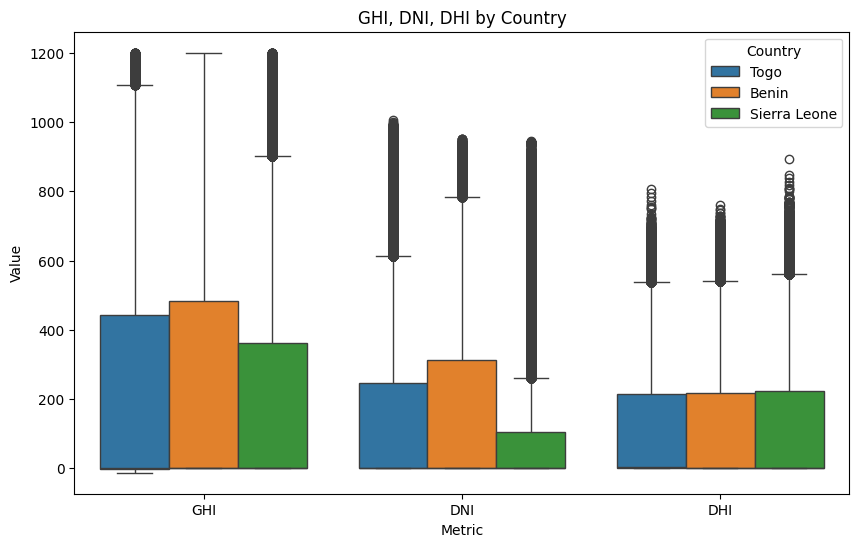

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format
metrics = ['GHI', 'DNI', 'DHI']
# Concatenate all data
df_all = pd.concat([df_cleaned_togo, df_cleaned_benin, df_cleaned_sierraleone], ignore_index=True)
df_long = df_all.melt(id_vars='Country', value_vars=metrics, var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Country', data=df_long)
plt.title('GHI, DNI, DHI by Country')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.legend(title='Country')
plt.show()

## Summary Table

In [5]:
metrics = ['GHI', 'DNI', 'DHI']

summary = df_all.groupby('Country')[metrics].agg(['mean', 'median', 'std'])
display(summary)

GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         241.696775    1.8  329.640184  167.296865    0.0  261.372925   
Sierra Leone  202.978391    0.2  294.422057  115.610516    0.0  217.269382   
Togo          230.024549    2.0  321.729321  150.949347    0.0  250.628916   

                     DHI                     
                    mean median         std  
Country                                      
Benin         116.911303    1.5  157.352720  
Sierra Leone  115.786310    0.0  156.515363  
Togo          116.248240    2.5  156.289096

## Statistical Testing 
### since it has been observed that the distributions are right skewed from the indivisual country analysis, we will use the non-parametric Kruskal-Wallis test

## Kruskal–Wallis test

In [6]:
from scipy.stats import kruskal

# Extract GHI values for each country
ghi_togo = df_cleaned_togo['GHI'].dropna()
ghi_benin = df_cleaned_benin['GHI'].dropna()
ghi_sierraleone = df_cleaned_sierraleone['GHI'].dropna()

In [7]:
kruskal_stat, kruskal_p = kruskal(ghi_togo, ghi_benin, ghi_sierraleone)
print(f"Kruskal–Wallis p-value: {kruskal_p:.4f}")

Kruskal–Wallis p-value: 0.0000


In [8]:
if kruskal_p < 0.05:
    print("Kruskal–Wallis: Significant differences in GHI between countries (p < 0.05).")
else:
    print("Kruskal–Wallis: No significant differences in GHI between countries (p >= 0.05).")

Kruskal–Wallis: Significant differences in GHI between countries (p < 0.05).


## Key Findings

## Benin and Togo show higher average (mean) values for all three irradiance measures (GHI, DNI, DHI) compared to Sierra Leone, indicating generally greater solar resource availability in those countries.​

## Median values for all irradiance metrics are notably low—especially in Sierra Leone (median GHI and DNI = 0)—suggesting either a highly skewed distribution, frequent zero or near-zero values, or significant periods with little solar irradiance in the dataset

## Statistical testing (Kruskal–Wallis) confirms significant differences in GHI distributions between countries (p < 0.05), indicating their solar resource potentials are not equal

## Ranking Countries by average GHI

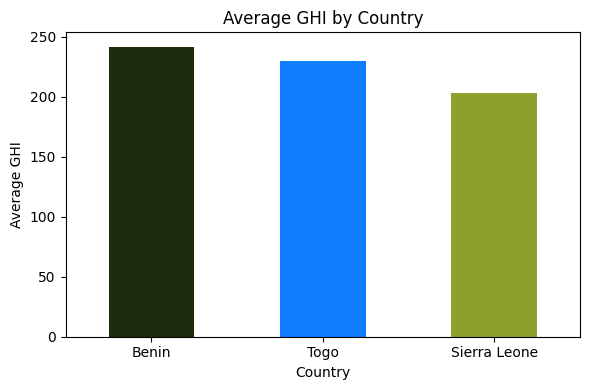

In [11]:
import matplotlib.pyplot as plt

# Calculate mean GHI for each country
mean_ghi = df_all.groupby('Country')['GHI'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
mean_ghi.plot(kind='bar', color=["#1b2d0d", "#0e7eff", "#8ea02c"])
plt.title('Average GHI by Country')
plt.xlabel('Country')
plt.ylabel('Average GHI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()